# Auckland Property Price Prediction -- Full Pipeline (original + external + new features)

Rebuilds the whole pipeline with three feature groups:

1. **Original** -- native Auckland Council DVR columns (and features derived only from them).
2. **Existing external** -- geocoded coordinates / suburb, Unitary Plan zone, flood-hazard layers.
3. **New external** -- from `cache/dvrs_noise_consents_features.parquet` (aircraft-noise overlays, SA2 new-dwelling consents) and `cache/dvrs_travel_features.parquet` (distance to nearest supermarket / bus stop, straight-line, walking and driving network).

Pipeline stages: **1. Import & join  2. Preprocessing  3. EDA  4. Train/test prep  5. Train RF + XGBoost  6. SHAP  7. Feature-group ablation  8. Without `capital_value`.**

Target: `sale_price_gross`. Split: time-based (train on earlier sales, test on the most recent).

## 1. Import data

The two new parquet files are row-aligned with `dvrs_processed.parquet`: their `source_index` equals the base table's index, and their coordinates are identical (asserted below), so they are joined on the index.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)

df = pd.read_parquet("./cache/dvrs_processed.parquet")
noise = pd.read_parquet("./cache/dvrs_noise_consents_features.parquet").set_index("source_index")
travel = pd.read_parquet("./cache/dvrs_travel_features.parquet").set_index("source_index")
print(f"Base:            {df.shape}")
print(f"Noise/consents:  {noise.shape}")
print(f"Travel:          {travel.shape}")

# Alignment checks: same index, same coordinates
for name, feat in [("noise/consents", noise), ("travel", travel)]:
    assert feat.index.equals(df.index), f"{name}: index mismatch"
    assert np.allclose(df["longitude"].astype(float), feat["longitude"]), f"{name}: longitude mismatch"
    assert np.allclose(df["latitude"].astype(float), feat["latitude"]), f"{name}: latitude mismatch"
print("Alignment OK: both feature tables match the base table row-for-row")

NOISE_COLS = ["noise_category_combination", "noise_match_status", "sa2_new_dwellings_consented_12m"]
TRAVEL_COLS = [
    "inside_auckland",
    "supermarket_euclidean_m", "bus_stop_euclidean_m",
    "walk_supermarket_network_m", "walk_bus_stop_network_m",
    "drive_supermarket_network_m", "drive_bus_stop_network_m",
]
df = df.join(noise[NOISE_COLS]).join(travel[TRAVEL_COLS])
print(f"Joined table:    {df.shape}")

Base:            (90738, 53)
Noise/consents:  (90738, 19)
Travel:          (90738, 31)
Alignment OK: both feature tables match the base table row-for-row
Joined table:    (90738, 63)


## 2. Data preprocessing

### 2.1 Filter to reliable, genuine owner-occupier market sales

- `zoning` (first digit 9, 1, 2): residential, rural and lifestyle zones; drops commercial / industrial / community properties (e.g. a supermarket building).
- `units_of_use == "1"`: a single unit rather than a block of several. Much other council data is only supplied when units = 1.
- `sale_tenure == "1"`: freehold sales (owning land + property), not leasehold.
- `sale_type == "S"`: any other type means several properties sold at once, so the price is a combined price while the features describe one property.
- `price_value_relationship == "1"`: arm's-length sale at market price.
- `street_in_linz`: the street exists in LINZ's address register, so the geocoded coordinates (and everything derived from them) are trustworthy.

In [2]:
before = len(df)
df = df[df["zoning"].astype(str).str[0].isin(["9", "1", "2"])]
print(f"Residential / rural / lifestyle zoning only (first digit 9, 1, 2): {len(df):,} / {before:,} rows kept")

before = len(df)
df = df[df["units_of_use"].astype(str) == "1"]
print(f"Single unit of use only (units_of_use == '1'): {len(df):,} / {before:,} rows kept")

before = len(df)
df = df[df["sale_tenure"].astype(str) == "1"]
print(f"Freehold sales only (sale_tenure == '1'): {len(df):,} / {before:,} rows kept")

before = len(df)
df = df[df["sale_type"] == "S"]
print(f"Single-property sales only (sale_type == 'S'): {len(df):,} / {before:,} rows kept")

before = len(df)
df = df[df["price_value_relationship"] == "1"]
print(f"Arm's-length market sales only (price_value_relationship == '1'): {len(df):,} / {before:,} rows kept")

before = len(df)
df = df[df["street_in_linz"]]
print(f"Geocoded street confirmed to exist in LINZ: {len(df):,} / {before:,} rows kept")

print()
print(f"Final filtered shape: {df.shape}")

Residential / rural / lifestyle zoning only (first digit 9, 1, 2): 80,070 / 90,738 rows kept
Single unit of use only (units_of_use == '1'): 77,370 / 80,070 rows kept
Freehold sales only (sale_tenure == '1'): 76,395 / 77,370 rows kept
Single-property sales only (sale_type == 'S'): 74,112 / 76,395 rows kept
Arm's-length market sales only (price_value_relationship == '1'): 61,244 / 74,112 rows kept


Geocoded street confirmed to exist in LINZ: 57,044 / 61,244 rows kept

Final filtered shape: (57044, 63)


### 2.2 Parse dates

In [3]:
def parse_sale_date(s):
    if pd.isna(s):
        return pd.NaT
    s = str(s)
    year = int(s[-4:])
    month = int(s[-6:-4])
    day = int(s[:-6])
    return pd.Timestamp(year=year, month=month, day=day)


df["sale_date_parsed"] = df["sale_date"].apply(parse_sale_date)

df["current_effective_valuation_date_parsed"] = pd.to_datetime(
    df["current_effective_valuation_date"].astype(int), unit="D", origin="1899-12-30"
)

print("sale_date_parsed range:", df["sale_date_parsed"].min().date(), "to", df["sale_date_parsed"].max().date())

sale_date_parsed range: 2024-01-01 to 2026-08-18


### 2.3 Convert numeric columns

In [4]:
numeric_cols = [
    "sale_price_gross", "sale_price_net", "sale_price_chattels", "sale_price_other",
    "capital_value", "land_value", "land_area", "building_total_floor_area",
    "mass_total_floor_area", "building_site_coverage", "off_street_parking",
    "units_of_use", "mass_garage_under_main_roof", "mass_garage_freestanding",
    "longitude", "latitude",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# New external numeric columns (some are nullable Int64 / float already)
new_numeric_cols = [
    "sa2_new_dwellings_consented_12m",
    "supermarket_euclidean_m", "bus_stop_euclidean_m",
    "walk_supermarket_network_m", "walk_bus_stop_network_m",
    "drive_supermarket_network_m", "drive_bus_stop_network_m",
]
for col in new_numeric_cols:
    df[col] = df[col].astype(float)

df[numeric_cols + new_numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sale_price_gross,57044.0,1.214143e+06,8.892736e+05,8.500000e+02,800000.000000,1.000000e+06,1.371000e+06,5.995000e+07
sale_price_net,57044.0,1.015926e+06,2.190803e+07,-2.649956e+09,787000.000000,9.880000e+05,1.355000e+06,5.995000e+07
sale_price_chattels,57044.0,1.981760e+05,2.188810e+07,0.000000e+00,8000.000000,1.500000e+04,2.000000e+04,2.651081e+09
sale_price_other,57044.0,1.320724e+01,2.721357e+03,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,6.400000e+05
capital_value,57044.0,1.265744e+06,8.535227e+05,0.000000e+00,840000.000000,1.075000e+06,1.436250e+06,6.250000e+07
land_value,57044.0,8.241030e+05,6.831466e+05,0.000000e+00,470000.000000,6.600000e+05,9.700000e+05,6.250000e+07
land_area,57044.0,2.037033e-01,3.622170e+00,0.000000e+00,0.007100,3.570000e-02,6.730000e-02,4.820000e+02
building_total_floor_area,57044.0,1.647025e+02,2.262381e+03,0.000000e+00,97.000000,1.340000e+02,1.880000e+02,3.600000e+05
mass_total_floor_area,57044.0,1.299488e+02,6.278368e+01,0.000000e+00,91.000000,1.180000e+02,1.600000e+02,9.260000e+02
building_site_coverage,57044.0,1.180573e+02,2.513752e+03,0.000000e+00,70.000000,1.000000e+02,1.380000e+02,6.000600e+05


### 2.4 Feature engineering

- Date parts, `property_type`, `land_value_ratio`, `has_flood_risk` (as before).
- `in_noise_overlay`: the property sits inside a mapped aircraft-noise overlay. The overlay snapshot is the *current* one (a long-term planning proxy), not the one in force at sale time, so treat it as a static location attribute.
- `noise_category_combination`: which overlay ("none" when outside all of them).

In [5]:
df["sale_year"] = df["sale_date_parsed"].dt.year
df["sale_month"] = df["sale_date_parsed"].dt.month
df["sale_quarter"] = df["sale_date_parsed"].dt.quarter

df["property_type"] = df["property_category"].str[0]

df["land_value_ratio"] = df["land_value"] / df["capital_value"].replace(0, np.nan)

df["has_flood_risk"] = df["in_flood_plain"] | df["in_flood_sensitive_area"]

df["in_noise_overlay"] = df["noise_match_status"] != "outside_current_overlay"
df["noise_category_combination"] = df["noise_category_combination"].astype(str).replace(
    {"outside_current_overlay": "none"}
)

print(df["noise_category_combination"].value_counts())

noise_category_combination
none                                                    54697
Auckland Airport - aircraft noise notification area      1641
Auckland Airport - moderate aircraft noise area           623
Auckland Airport - high aircraft noise area                30
Whenuapai Airbase - noise control area (55dBA)             21
Ardmore Airport - outer control boundary (55dBA)           20
Whenuapai Airbase- noise control area (65dBA)               6
North Shore Airport - Outer control boundary (55dBA)        3
North Shore Airport - air noise boundary (65dBA)            2
Ardmore Airport - inner control boundary (60dBA)            1
Name: count, dtype: int64


### 2.5 Handle missing values

Categoricals with NaN become an explicit "Unknown" level. The new numeric features have two kinds of gaps: rows outside the Auckland extent (no SA2 / no network graph) and properties with no reachable supermarket / bus stop by walking or driving. Those are left as NaN here and median-imputed *after* the train/test split (section 5) so no test information leaks in.

In [6]:
missing = df.isna().mean().sort_values(ascending=False) * 100
print(missing[missing > 0].round(2))

valuation_number_suffix            82.46
additional_situation_number        68.02
walk_supermarket_network_m          2.89
building_condition_indicator        2.83
building_construction_indicator     2.80
building_age_indicator              2.70
walk_bus_stop_network_m             2.08
mass_other_improvements             1.85
mass_workshop_laundry               1.62
drive_supermarket_network_m         1.43
drive_bus_stop_network_m            1.43
mass_deck                           1.14
supermarket_euclidean_m             0.67
bus_stop_euclidean_m                0.67
unitary_plan_zone                   0.67
sa2_new_dwellings_consented_12m     0.67
mass_scope_of_view                  0.37
mass_view                           0.36
mass_contour                        0.33
matched_suburb                      0.01
land_value_ratio                    0.00
matched_postcode                    0.00
dtype: float64


In [7]:
categorical_with_unknown = [
    "building_age_indicator", "building_condition_indicator", "building_construction_indicator",
    "mass_contour", "mass_view", "mass_scope_of_view", "mass_deck", "mass_workshop_laundry",
    "mass_other_improvements", "zoning", "property_type", "matched_suburb",
]
for col in categorical_with_unknown:
    df[col] = df[col].fillna("Unknown")

# unitary_plan_zone: NaN means outside any mapped base-zone polygon -- a real category.
df["unitary_plan_zone"] = df["unitary_plan_zone"].fillna(-1).astype(int).astype(str)

# land_value_ratio: only undefined when capital_value is 0 -- median impute.
df["land_value_ratio"] = df["land_value_ratio"].fillna(df["land_value_ratio"].median())

remaining = df.isna().mean().sort_values(ascending=False) * 100
print(remaining[remaining > 0].round(2))

valuation_number_suffix            82.46
additional_situation_number        68.02
walk_supermarket_network_m          2.89
walk_bus_stop_network_m             2.08
drive_bus_stop_network_m            1.43
drive_supermarket_network_m         1.43
bus_stop_euclidean_m                0.67
supermarket_euclidean_m             0.67
sa2_new_dwellings_consented_12m     0.67
matched_postcode                    0.00
dtype: float64


### 2.6 Finalize columns, grouped by source

Features are declared per group so the ablation in section 7 can switch groups on and off. `sale_type` and `units_of_use` are constant after the filters and are left out. Identifiers, target-leaking price components (`sale_price_net/chattels/other`), high-cardinality codes and QA metadata (`geocode_confidence`, snap distances, status flags, `consents_*` diagnostics) are not model inputs.

In [8]:
target_col = "sale_price_gross"

FEATURE_GROUPS = {
    "original": {
        "cat": [
            "zoning", "building_age_indicator", "building_condition_indicator",
            "building_construction_indicator", "mass_contour", "mass_view", "mass_scope_of_view",
            "mass_deck", "mass_workshop_laundry", "mass_other_improvements",
            "property_type", "actual_property_use",
        ],
        "num": [
            "capital_value", "land_value", "land_area", "building_total_floor_area",
            "mass_total_floor_area", "building_site_coverage", "off_street_parking",
            "mass_garage_under_main_roof", "mass_garage_freestanding",
            "land_value_ratio", "sale_year", "sale_month", "sale_quarter",
        ],
        "bool": [],
    },
    "external_existing": {
        "cat": ["matched_suburb", "unitary_plan_zone"],
        "num": ["longitude", "latitude", "dist_to_flood_plain_m", "dist_to_flood_sensitive_area_m"],
        "bool": ["in_flood_plain", "in_flood_sensitive_area", "has_flood_risk"],
    },
    "external_new": {
        "cat": ["noise_category_combination"],
        "num": [
            "sa2_new_dwellings_consented_12m",
            "supermarket_euclidean_m", "bus_stop_euclidean_m",
            "walk_supermarket_network_m", "walk_bus_stop_network_m",
            "drive_supermarket_network_m", "drive_bus_stop_network_m",
        ],
        "bool": ["in_noise_overlay"],
    },
}

categorical_features = [c for g in FEATURE_GROUPS.values() for c in g["cat"]]
numeric_features = [c for g in FEATURE_GROUPS.values() for c in g["num"]]
boolean_features = [c for g in FEATURE_GROUPS.values() for c in g["bool"]]
feature_cols = categorical_features + numeric_features + boolean_features
group_of = {c: name for name, g in FEATURE_GROUPS.items() for kind in g.values() for c in kind}

df_model = df[feature_cols + [target_col, "sale_date_parsed"]].copy()
print(f"{len(feature_cols)} features, {df_model.shape[0]:,} rows")
print({name: sum(len(v) for v in g.values()) for name, g in FEATURE_GROUPS.items()})

43 features, 57,044 rows
{'original': 25, 'external_existing': 9, 'external_new': 9}


## 3. Data analysis (EDA)

### 3.1 Target distribution

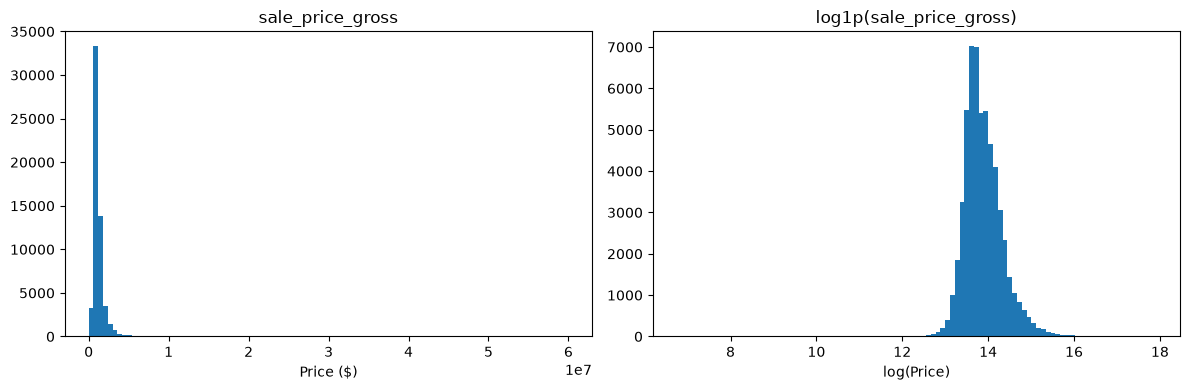

count    5.704400e+04
mean     1.214143e+06
std      8.892736e+05
min      8.500000e+02
25%      8.000000e+05
50%      1.000000e+06
75%      1.371000e+06
max      5.995000e+07
Name: sale_price_gross, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_model["sale_price_gross"], bins=100)
axes[0].set_title("sale_price_gross")
axes[0].set_xlabel("Price ($)")

axes[1].hist(np.log1p(df_model["sale_price_gross"]), bins=100)
axes[1].set_title("log1p(sale_price_gross)")
axes[1].set_xlabel("log(Price)")

plt.tight_layout()
plt.show()

print(df_model["sale_price_gross"].describe())

### 3.2 Numeric feature correlations

sale_price_gross                   1.000
capital_value                      0.955
land_value                         0.850
mass_total_floor_area              0.549
mass_garage_under_main_roof        0.258
latitude                           0.120
off_street_parking                 0.112
land_area                          0.081
land_value_ratio                   0.064
dist_to_flood_sensitive_area_m     0.044
walk_supermarket_network_m         0.036
supermarket_euclidean_m            0.033
drive_supermarket_network_m        0.029
bus_stop_euclidean_m               0.018
walk_bus_stop_network_m            0.017
building_total_floor_area          0.015
drive_bus_stop_network_m           0.015
longitude                          0.007
building_site_coverage             0.007
dist_to_flood_plain_m              0.003
mass_garage_freestanding          -0.007
sale_month                        -0.008
sale_quarter                      -0.011
sale_year                         -0.016
sa2_new_dwelling

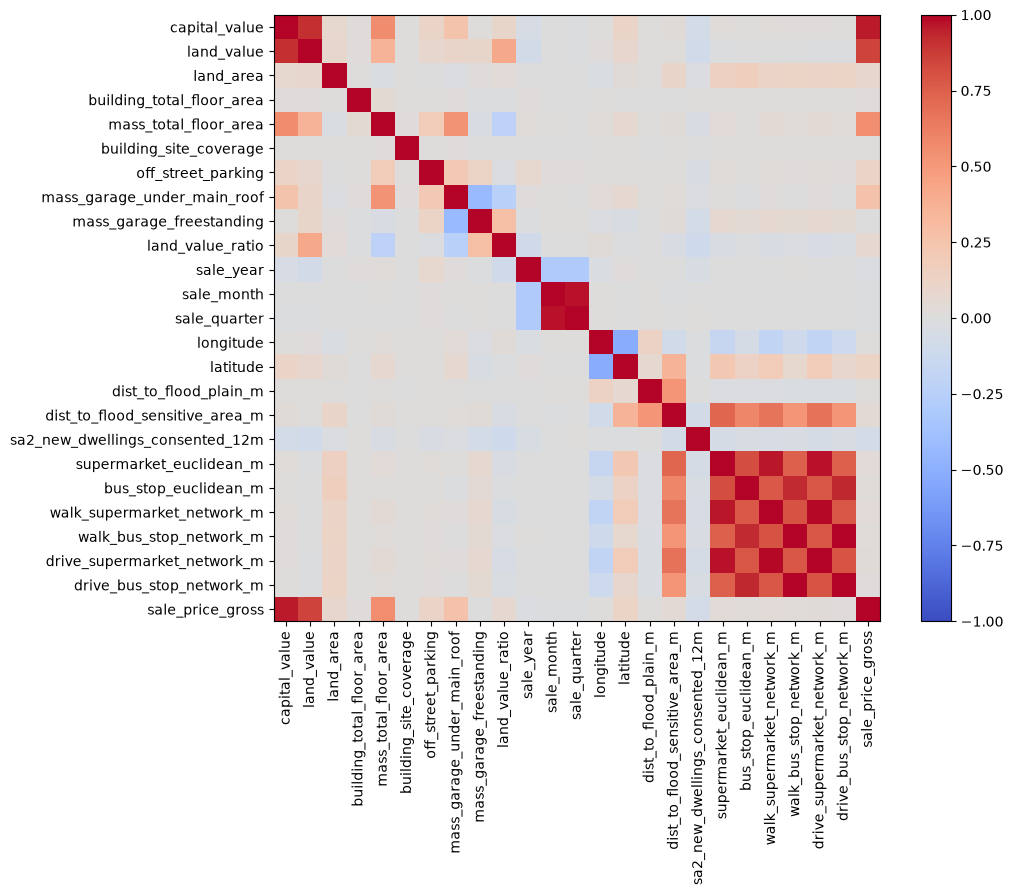

In [10]:
corr_matrix = df_model[numeric_features + [target_col]].corr()
print(corr_matrix[target_col].sort_values(ascending=False).round(3))

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
labels = list(corr_matrix.columns)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
plt.colorbar(im)
plt.tight_layout()
plt.show()

### 3.3 Categorical feature relationships

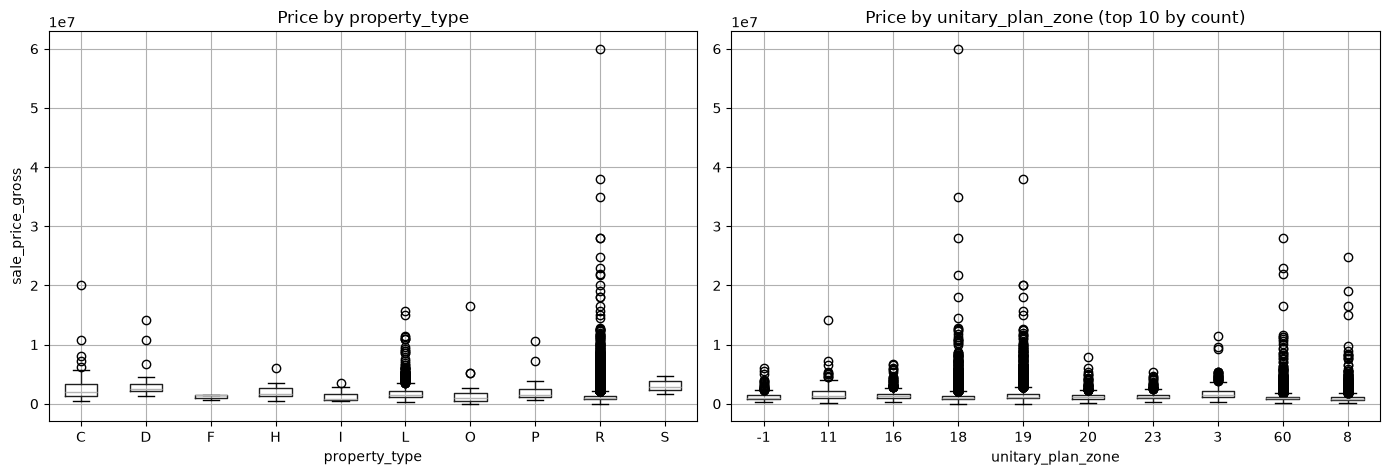

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_model.boxplot(column="sale_price_gross", by="property_type", ax=axes[0])
axes[0].set_title("Price by property_type")
axes[0].set_ylabel("sale_price_gross")

top_zones = df_model["unitary_plan_zone"].value_counts().head(10).index
df_model[df_model["unitary_plan_zone"].isin(top_zones)].boxplot(
    column="sale_price_gross", by="unitary_plan_zone", ax=axes[1]
)
axes[1].set_title("Price by unitary_plan_zone (top 10 by count)")

plt.suptitle("")
plt.tight_layout()
plt.show()

### 3.4 Geographic distribution

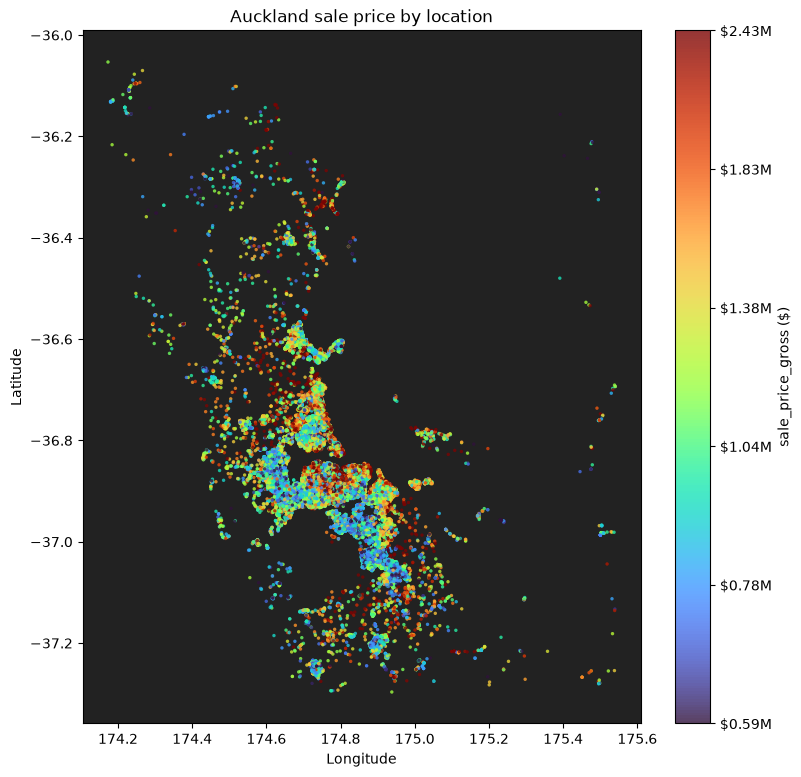

In [12]:
# Random draw order so no price band hides the others in dense areas; colour range
# clipped to the 5th-95th percentile so extreme prices don't wash out the contrast.
geo = df_model[["longitude", "latitude", "sale_price_gross"]].sample(frac=1, random_state=42)
geo_color = np.log1p(geo["sale_price_gross"])
vmin, vmax = geo_color.quantile([0.05, 0.95])

fig, ax = plt.subplots(figsize=(9, 9))
sc = ax.scatter(
    geo["longitude"], geo["latitude"],
    c=geo_color, cmap="turbo", vmin=vmin, vmax=vmax, s=6, alpha=0.8, linewidths=0,
)
cbar = plt.colorbar(sc, label="sale_price_gross ($)")
ticks = np.linspace(vmin, vmax, 6)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"${np.expm1(t) / 1e6:.2f}M" for t in ticks])
ax.set_facecolor("#222222")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Auckland sale price by location")
plt.show()

### 3.5 Price trend over time

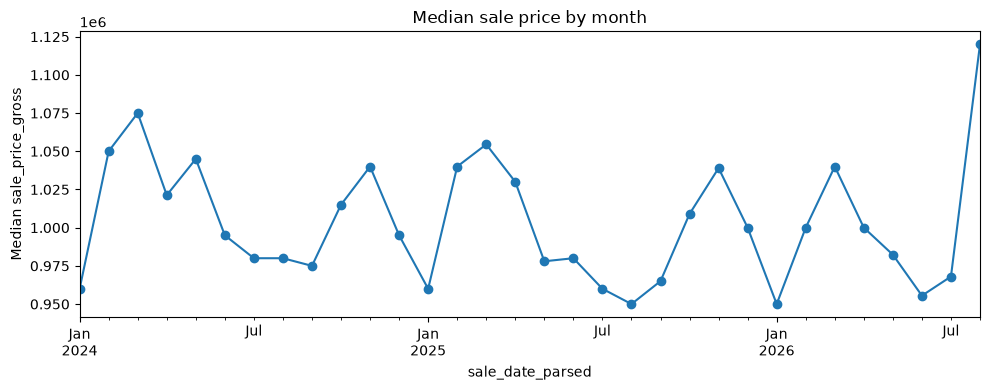

In [13]:
monthly = df_model.groupby(df_model["sale_date_parsed"].dt.to_period("M"))["sale_price_gross"].median()
fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, marker="o")
ax.set_ylabel("Median sale_price_gross")
ax.set_title("Median sale price by month")
plt.tight_layout()
plt.show()

### 3.6 Flood hazard impact on price

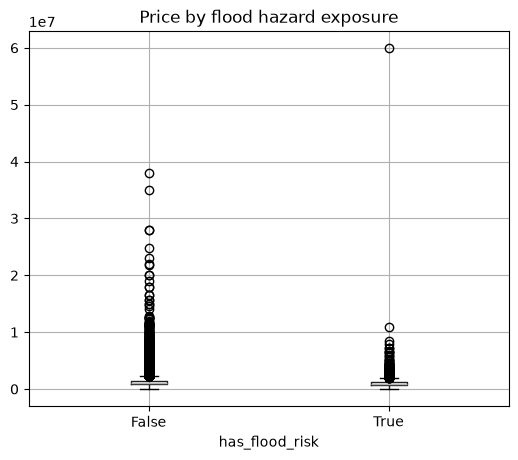

has_flood_risk
False    1015000.0
True      890000.0
Name: sale_price_gross, dtype: float64


In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
df_model.boxplot(column="sale_price_gross", by="has_flood_risk", ax=ax)
ax.set_title("Price by flood hazard exposure")
plt.suptitle("")
plt.show()

print(df_model.groupby("has_flood_risk")["sale_price_gross"].median())

### 3.7 New external features vs price

Median price across deciles of each new numeric feature, and price inside vs outside aircraft-noise overlays.

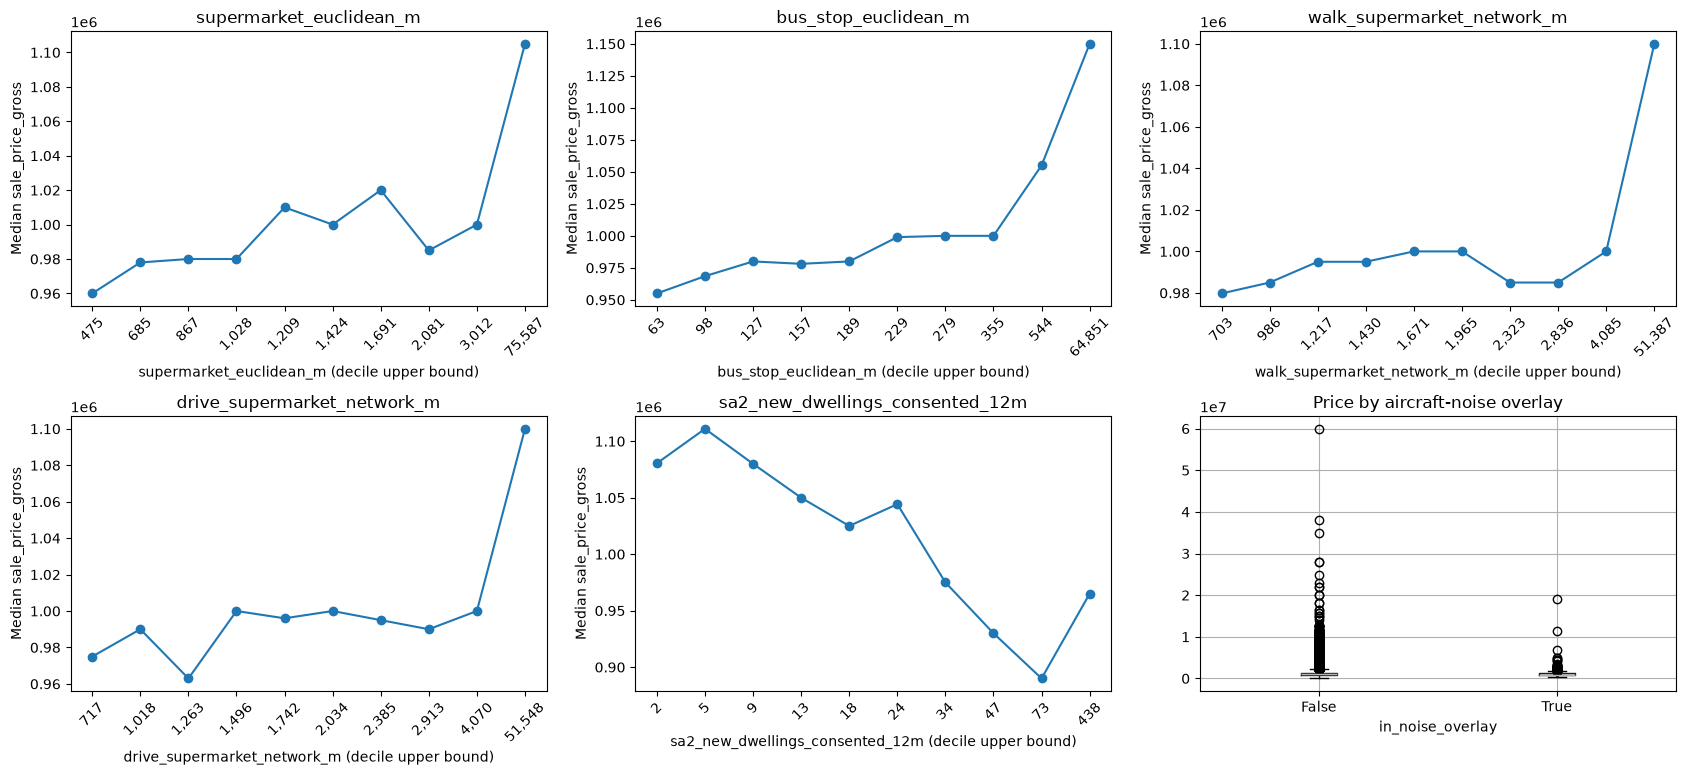

                  count     median
in_noise_overlay                  
False             54697  1008000.0
True               2347   877000.0


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, col in zip(axes.ravel()[:5], [
    "supermarket_euclidean_m", "bus_stop_euclidean_m",
    "walk_supermarket_network_m", "drive_supermarket_network_m",
    "sa2_new_dwellings_consented_12m",
]):
    bins = pd.qcut(df_model[col], 10, duplicates="drop")
    med = df_model.groupby(bins, observed=True)[target_col].median()
    ax.plot(range(len(med)), med.values, marker="o")
    ax.set_xticks(range(len(med)))
    ax.set_xticklabels([f"{iv.right:,.0f}" for iv in med.index], rotation=45)
    ax.set_xlabel(f"{col} (decile upper bound)")
    ax.set_ylabel("Median sale_price_gross")
    ax.set_title(col)

df_model.boxplot(column=target_col, by="in_noise_overlay", ax=axes[1, 2])
axes[1, 2].set_title("Price by aircraft-noise overlay")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(df_model.groupby("in_noise_overlay")[target_col].agg(["count", "median"]))

## 4. Prepare for running the model

### 4.1 Feature groups

In [16]:
for col in categorical_features:
    df_model[col] = df_model[col].astype(str)

X = df_model[feature_cols + ["sale_date_parsed"]].copy()  # keep the date to drive the split, drop it after
y = df_model[target_col].copy()

pd.DataFrame({
    "feature": feature_cols,
    "group": [group_of[c] for c in feature_cols],
    "type": ["categorical"] * len(categorical_features) + ["numeric"] * len(numeric_features) + ["boolean"] * len(boolean_features),
}).groupby(["group", "type"])["feature"].apply(lambda s: ", ".join(s))

group              type       
external_existing  boolean        in_flood_plain, in_flood_sensitive_area, has_f...
                   categorical                    matched_suburb, unitary_plan_zone
                   numeric        longitude, latitude, dist_to_flood_plain_m, di...
external_new       boolean                                         in_noise_overlay
                   categorical                           noise_category_combination
                   numeric        sa2_new_dwellings_consented_12m, supermarket_e...
original           categorical    zoning, building_age_indicator, building_condi...
                   numeric        capital_value, land_value, land_area, building...
Name: feature, dtype: str

## Dataset description

| Group | Feature | Type | Source / meaning |
|---|---|---|---|
| Original | `zoning`, `actual_property_use`, `property_type` | categorical | Council zoning code, actual use, first character of `property_category` |
| Original | `building_age_indicator`, `building_condition_indicator`, `building_construction_indicator` | categorical | Building descriptors |
| Original | `mass_contour`, `mass_view`, `mass_scope_of_view`, `mass_deck`, `mass_workshop_laundry`, `mass_other_improvements` | categorical | Building-mass descriptors |
| Original | `capital_value`, `land_value` | numeric | Council valuation of property / land |
| Original | `land_area`, `building_total_floor_area`, `mass_total_floor_area`, `building_site_coverage` | numeric | Sizes |
| Original | `off_street_parking`, `mass_garage_under_main_roof`, `mass_garage_freestanding` | numeric | Parking / garages |
| Original (derived) | `land_value_ratio`, `sale_year`, `sale_month`, `sale_quarter` | numeric | `land_value / capital_value`; date parts |
| Existing external | `longitude`, `latitude`, `matched_suburb` | numeric / categorical | LINZ address geocoding |
| Existing external | `unitary_plan_zone` | categorical | Unitary Plan base zone (GIS spatial join) |
| Existing external | `dist_to_flood_plain_m`, `dist_to_flood_sensitive_area_m`, `in_flood_plain`, `in_flood_sensitive_area`, `has_flood_risk` | numeric / boolean | Council flood-hazard layers |
| **New external** | `noise_category_combination`, `in_noise_overlay` | categorical / boolean | Aircraft-noise overlay the property sits in (current snapshot) |
| **New external** | `sa2_new_dwellings_consented_12m` | numeric | New dwellings consented in the property's SA2 in the 12 months before sale (release-specific snapshot) |
| **New external** | `supermarket_euclidean_m`, `bus_stop_euclidean_m` | numeric | Straight-line distance to nearest supermarket / bus stop (m) |
| **New external** | `walk_*_network_m`, `drive_*_network_m` (supermarket, bus stop) | numeric | Road-network walking / driving distance (m) |

### 4.2 Time-based train/test split

In [17]:
X_sorted = X.sort_values("sale_date_parsed")
y_sorted = y.loc[X_sorted.index]

split_date = X_sorted["sale_date_parsed"].quantile(0.85, interpolation="nearest")
print(f"Train/test split date: {split_date.date()}")

train_mask = X_sorted["sale_date_parsed"] <= split_date
X_train = X_sorted.loc[train_mask, feature_cols]
X_test = X_sorted.loc[~train_mask, feature_cols]
y_train = y_sorted.loc[train_mask]
y_test = y_sorted.loc[~train_mask]

train_dates = X_sorted.loc[train_mask, "sale_date_parsed"]
test_dates = X_sorted.loc[~train_mask, "sale_date_parsed"]
print(f"Train: {len(X_train):,} rows ({train_dates.min().date()} to {train_dates.max().date()})")
print(f"Test:  {len(X_test):,} rows ({test_dates.min().date()} to {test_dates.max().date()})")

Train/test split date: 2026-02-11
Train: 48,566 rows (2024-01-01 to 2026-02-11)
Test:  8,478 rows (2026-02-12 to 2026-08-18)


### 4.3 Save prepared datasets

In [18]:
MODEL_DATA_DIR = Path("./cache/model_ready_tmp2")
MODEL_DATA_DIR.mkdir(parents=True, exist_ok=True)

X_train.to_parquet(MODEL_DATA_DIR / "X_train.parquet")
X_test.to_parquet(MODEL_DATA_DIR / "X_test.parquet")
y_train.to_frame(name=target_col).to_parquet(MODEL_DATA_DIR / "y_train.parquet")
y_test.to_frame(name=target_col).to_parquet(MODEL_DATA_DIR / "y_test.parquet")

print(f"Saved train/test sets to {MODEL_DATA_DIR}/")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Saved train/test sets to cache\model_ready_tmp2/
X_train: (48566, 43), X_test: (8478, 43)


## 5. Train Random Forest and XGBoost

### 5.1 Trim price outliers (fit on train only)

In [19]:
p1, p99 = y_train.quantile([0.01, 0.99])
print(f"Keeping prices in [${p1:,.0f}, ${p99:,.0f}] (1st-99th percentile of train)")

train_keep = y_train.between(p1, p99)
test_keep = y_test.between(p1, p99)

X_train_f = X_train[train_keep].copy()
y_train_f = y_train[train_keep].copy()
X_test_f = X_test[test_keep].copy()
y_test_f = y_test[test_keep].copy()

print(f"Train: {len(X_train_f):,} / {len(X_train):,} kept")
print(f"Test:  {len(X_test_f):,} / {len(X_test):,} kept")

Keeping prices in [$460,000, $4,287,000] (1st-99th percentile of train)
Train: 47,617 / 48,566 kept
Test:  8,324 / 8,478 kept


### 5.2 Encode categorical features

In [20]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
encoder.fit(X_train_f[categorical_features])

X_train_enc = X_train_f.copy()
X_test_enc = X_test_f.copy()
X_train_enc[categorical_features] = encoder.transform(X_train_f[categorical_features])
X_test_enc[categorical_features] = encoder.transform(X_test_f[categorical_features])

# booleans -> 0/1
for col in boolean_features:
    X_train_enc[col] = X_train_enc[col].astype(int)
    X_test_enc[col] = X_test_enc[col].astype(int)

X_train_enc = X_train_enc.astype(float)
X_test_enc = X_test_enc.astype(float)

### 5.2a Impute remaining numeric gaps (train medians)

Only the new external numeric features still contain NaN (outside-Auckland-extent rows and properties with no reachable facility). Medians are fitted on the training set and applied to both sets.

In [21]:
nan_cols = [c for c in numeric_features if X_train_enc[c].isna().any() or X_test_enc[c].isna().any()]
print("Columns with NaN before imputing:")
print(X_train_enc[nan_cols].isna().mean().round(4).rename("train_nan_share").to_frame())

train_medians = X_train_enc[nan_cols].median()
X_train_enc[nan_cols] = X_train_enc[nan_cols].fillna(train_medians)
X_test_enc[nan_cols] = X_test_enc[nan_cols].fillna(train_medians)
print("\nNaN left:", int(X_train_enc.isna().sum().sum() + X_test_enc.isna().sum().sum()))

Columns with NaN before imputing:
                                 train_nan_share
sa2_new_dwellings_consented_12m           0.0070
supermarket_euclidean_m                   0.0070
bus_stop_euclidean_m                      0.0070
walk_supermarket_network_m                0.0282
walk_bus_stop_network_m                   0.0203
drive_supermarket_network_m               0.0142
drive_bus_stop_network_m                  0.0142

NaN left: 0


### 5.2b Log-transform heavily skewed monetary / size / distance features

In [22]:
skewed_cols = [
    "capital_value", "land_value", "land_area", "building_total_floor_area", "mass_total_floor_area",
    "supermarket_euclidean_m", "bus_stop_euclidean_m",
    "walk_supermarket_network_m", "walk_bus_stop_network_m",
    "drive_supermarket_network_m", "drive_bus_stop_network_m",
]
for col in skewed_cols:
    X_train_enc[col] = np.log1p(X_train_enc[col])
    X_test_enc[col] = np.log1p(X_test_enc[col])

X_train_enc[skewed_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
capital_value,47617.0,13.936398,0.409172,0.00000,13.641158,13.887832,14.180154,16.380460
land_value,47617.0,13.451582,0.533137,0.00000,13.060490,13.415034,13.785052,16.334013
land_area,47617.0,0.073602,0.238275,0.00000,0.007174,0.034595,0.064757,5.525115
building_total_floor_area,47617.0,4.800410,0.889507,0.00000,4.584967,4.897840,5.231109,9.211640
mass_total_floor_area,47617.0,4.681683,0.880394,0.00000,4.521789,4.770685,5.068904,6.548219
supermarket_euclidean_m,47617.0,7.122860,0.815167,2.41612,6.664171,7.102314,7.534439,11.233055
bus_stop_euclidean_m,47617.0,5.288789,1.038733,1.91254,4.732184,5.247268,5.737070,11.077715
walk_supermarket_network_m,47617.0,7.457971,0.779770,0.00000,7.029342,7.424792,7.831250,10.847162
walk_bus_stop_network_m,47617.0,5.590364,1.313532,0.00000,5.118359,5.676396,6.160642,10.583221
drive_supermarket_network_m,47617.0,7.478777,0.797024,0.00000,7.048324,7.466058,7.869054,10.850282


### 5.2c Multicollinearity pruning

For each pair of numeric features with |r| > 0.7 (on the training set), drop whichever correlates less strongly with the target and keep the more predictive one. Expect the straight-line / walking / driving distances to be pruned against each other.

In [23]:
corr_matrix = X_train_enc[numeric_features].corr()

to_drop = set()
pair_decisions = []
for i, a in enumerate(numeric_features):
    for b in numeric_features[i + 1:]:
        r = corr_matrix.loc[a, b]
        if abs(r) > 0.7:
            corr_a_target = abs(X_train_enc[a].corr(y_train_f))
            corr_b_target = abs(X_train_enc[b].corr(y_train_f))
            drop_col, keep_col = (a, b) if corr_a_target < corr_b_target else (b, a)
            to_drop.add(drop_col)
            pair_decisions.append((a, b, r, drop_col, keep_col, corr_a_target, corr_b_target))

print(f"{len(pair_decisions)} feature pair(s) exceeded |r| > 0.7:")
for a, b, r, drop_col, keep_col, corr_a_target, corr_b_target in pair_decisions:
    print(
        f"  {a} vs {b}: r={r:.3f}  "
        f"(corr with target: {a}={corr_a_target:.3f}, {b}={corr_b_target:.3f})  "
        f"-> dropping '{drop_col}', keeping '{keep_col}'"
    )

print(f"\nDropping {len(to_drop)} redundant feature(s): {sorted(to_drop)}")

numeric_features_pruned = [c for c in numeric_features if c not in to_drop]
X_train_enc = X_train_enc.drop(columns=list(to_drop))
X_test_enc = X_test_enc.drop(columns=list(to_drop))

final_cols = list(X_train_enc.columns)
print(f"Remaining features: {len(final_cols)} (numeric: {len(numeric_features_pruned)})")
print({g: sum(group_of[c] == g for c in final_cols) for g in FEATURE_GROUPS})

9 feature pair(s) exceeded |r| > 0.7:
  capital_value vs land_value: r=0.841  (corr with target: capital_value=0.882, land_value=0.729)  -> dropping 'land_value', keeping 'capital_value'
  building_total_floor_area vs mass_total_floor_area: r=0.950  (corr with target: building_total_floor_area=0.334, mass_total_floor_area=0.302)  -> dropping 'mass_total_floor_area', keeping 'building_total_floor_area'
  sale_month vs sale_quarter: r=0.973  (corr with target: sale_month=0.001, sale_quarter=0.005)  -> dropping 'sale_month', keeping 'sale_quarter'
  supermarket_euclidean_m vs walk_supermarket_network_m: r=0.933  (corr with target: supermarket_euclidean_m=0.051, walk_supermarket_network_m=0.041)  -> dropping 'walk_supermarket_network_m', keeping 'supermarket_euclidean_m'
  supermarket_euclidean_m vs drive_supermarket_network_m: r=0.934  (corr with target: supermarket_euclidean_m=0.051, drive_supermarket_network_m=0.033)  -> dropping 'drive_supermarket_network_m', keeping 'supermarket_eucli

Remaining features: 36 (numeric: 17)
{'original': 22, 'external_existing': 9, 'external_new': 5}


### 5.3 Random Forest

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_train_enc, y_train_f)
print("Random Forest trained")

Random Forest trained


### 5.4 XGBoost

In [25]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train_enc, y_train_f)
print("XGBoost trained")

XGBoost trained


### 5.5 Evaluate on the test set

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate(name, model, X, y_true, verbose=True):
    y_pred = model.predict(X)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    if verbose:
        print(f"{name:15s}  RMSE=${rmse:,.0f}   MAE=${mae:,.0f}   R2={r2:.4f}")
    return y_pred


rf_pred = evaluate("Random Forest", rf_model, X_test_enc, y_test_f)
xgb_pred = evaluate("XGBoost", xgb_model, X_test_enc, y_test_f)

Random Forest    RMSE=$133,315   MAE=$87,283   R2=0.9388
XGBoost          RMSE=$130,692   MAE=$86,340   R2=0.9412


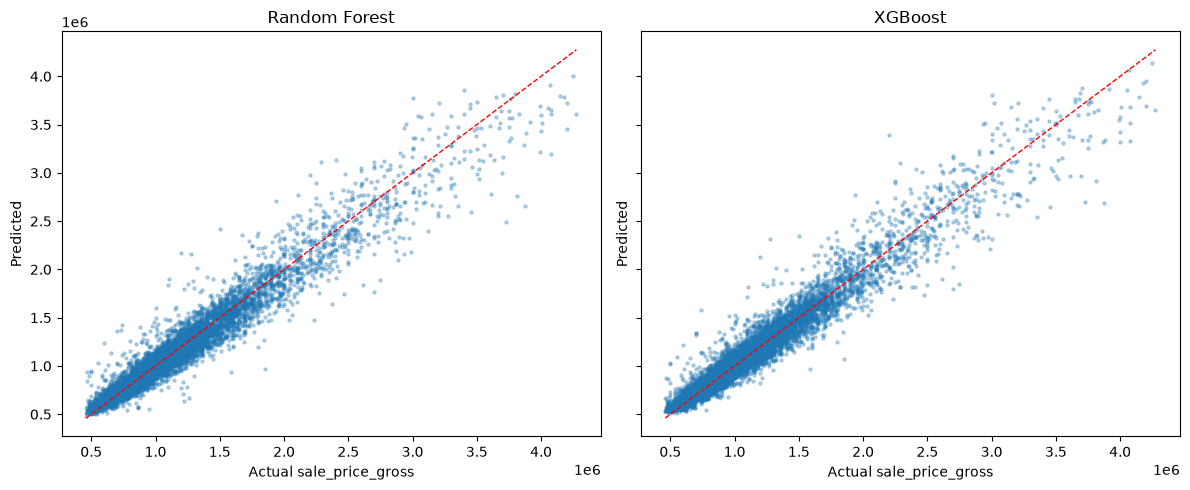

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, name, pred in zip(axes, ["Random Forest", "XGBoost"], [rf_pred, xgb_pred]):
    ax.scatter(y_test_f, pred, s=5, alpha=0.3)
    lims = [y_test_f.min(), y_test_f.max()]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("Actual sale_price_gross")
    ax.set_ylabel("Predicted")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 6. Explain feature importance with SHAP

In [28]:
import shap

shap_sample = X_test_enc.sample(n=min(300, len(X_test_enc)), random_state=42)
print(f"Computing SHAP values on a sample of {len(shap_sample):,} test rows")

D:\Codes\COMPSCI_760_Group_3_Intelligent_Real_Estate_Price_Prediction_Model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing SHAP values on a sample of 300 test rows


### 6.1 Random Forest feature importance

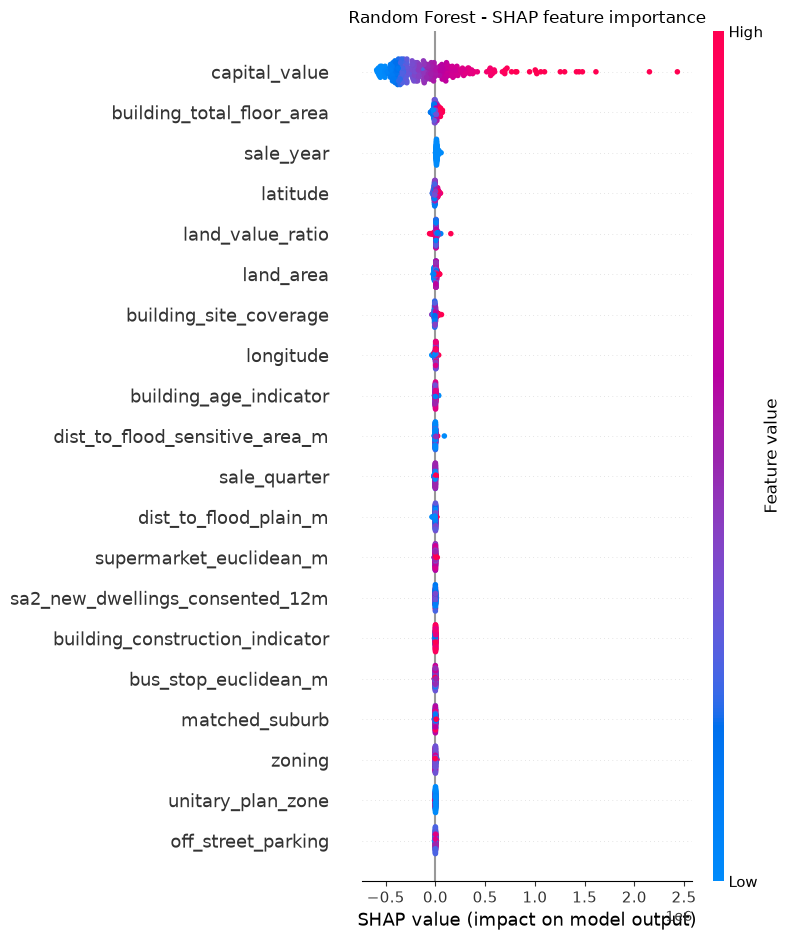

In [29]:
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(shap_sample)

shap.summary_plot(rf_shap_values, shap_sample, show=False)
plt.title("Random Forest - SHAP feature importance")
plt.tight_layout()
plt.show()

### 6.2 XGBoost feature importance

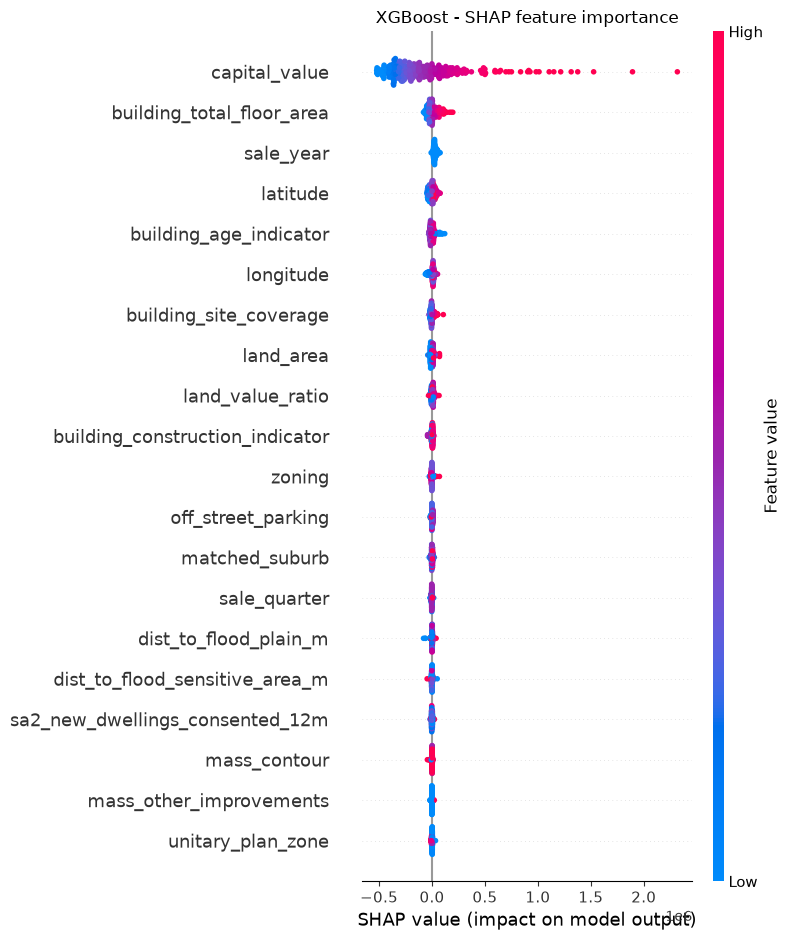

In [30]:
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(shap_sample)

shap.summary_plot(xgb_shap_values, shap_sample, show=False)
plt.title("XGBoost - SHAP feature importance")
plt.tight_layout()
plt.show()

### 6.3 Compare mean |SHAP| ranking (with feature group)

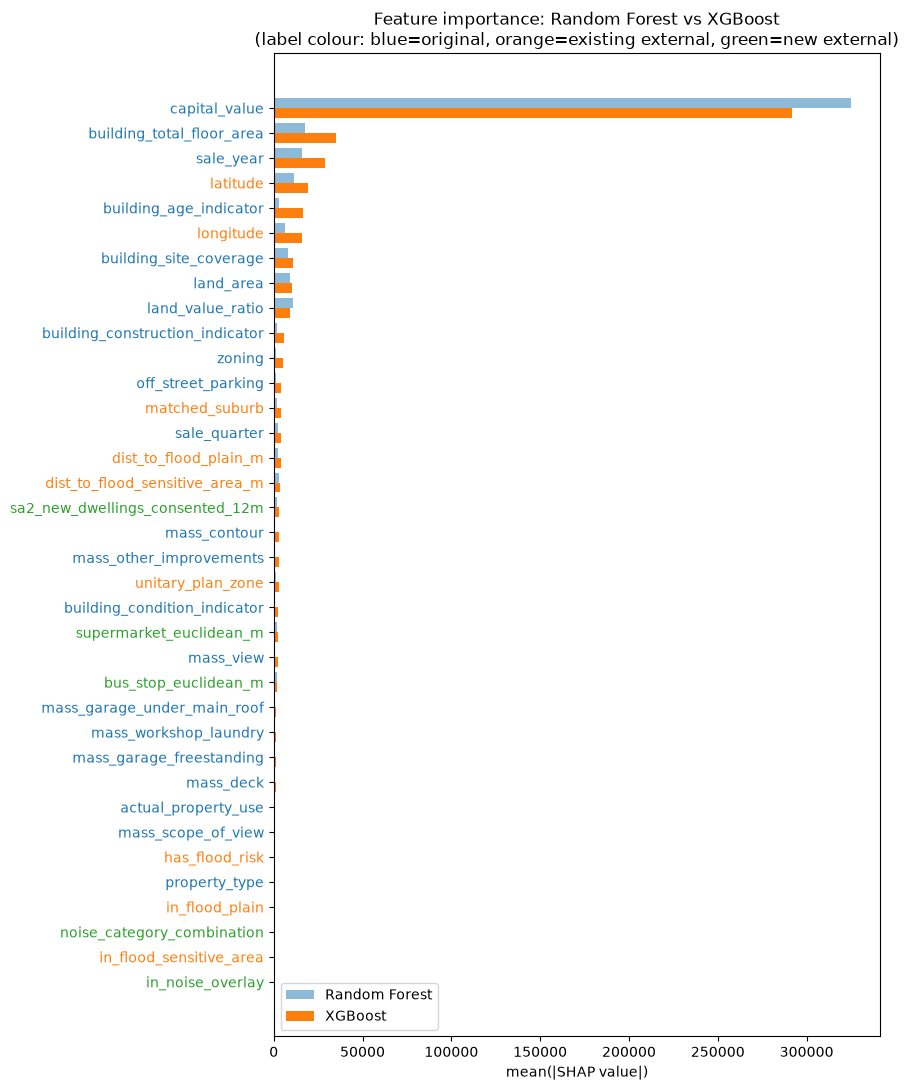

,feature,group,rf_mean_abs_shap,xgb_mean_abs_shap
15,capital_value,original,325066.766771,291605.187500
17,building_total_floor_area,original,17888.349009,35281.367188
23,sale_year,original,16041.978196,28780.220703
26,latitude,external_existing,11337.636134,19081.919922
1,building_age_indicator,original,3045.759785,16411.794922
25,longitude,external_existing,6262.770148,15823.299805
18,building_site_coverage,original,7912.692317,11055.916016
16,land_area,original,8901.173647,10177.690430
22,land_value_ratio,original,10616.281940,8885.357422
3,building_construction_indicator,original,1782.510307,5538.003906


In [31]:
importance_comparison = pd.DataFrame({
    "feature": shap_sample.columns,
    "group": [group_of[c] for c in shap_sample.columns],
    "rf_mean_abs_shap": np.abs(rf_shap_values).mean(axis=0),
    "xgb_mean_abs_shap": np.abs(xgb_shap_values).mean(axis=0),
}).sort_values("xgb_mean_abs_shap", ascending=False)

group_colors = {"original": "tab:blue", "external_existing": "tab:orange", "external_new": "tab:green"}
fig, ax = plt.subplots(figsize=(9, 11))
y_pos = np.arange(len(importance_comparison))
ax.barh(y_pos - 0.2, importance_comparison["rf_mean_abs_shap"], height=0.4, label="Random Forest", alpha=0.5)
ax.barh(y_pos + 0.2, importance_comparison["xgb_mean_abs_shap"], height=0.4, label="XGBoost")
ax.set_yticks(y_pos)
ax.set_yticklabels(importance_comparison["feature"])
for tick, grp in zip(ax.get_yticklabels(), importance_comparison["group"]):
    tick.set_color(group_colors[grp])
ax.invert_yaxis()
ax.set_xlabel("mean(|SHAP value|)")
ax.set_title("Feature importance: Random Forest vs XGBoost\n(label colour: blue=original, orange=existing external, green=new external)")
ax.legend()
plt.tight_layout()
plt.show()

importance_comparison.head(20)

In [32]:
group_share = importance_comparison.groupby("group")[["rf_mean_abs_shap", "xgb_mean_abs_shap"]].sum()
group_share = group_share / group_share.sum()
print("Share of total mean |SHAP| by feature group:")
print(group_share.round(3))

Share of total mean |SHAP| by feature group:
                   rf_mean_abs_shap  xgb_mean_abs_shap
group                                                 
external_existing             0.060              0.100
external_new                  0.013              0.016
original                      0.927              0.884


## 7. Feature-group ablation

Retrain both models on progressively richer feature sets, using the same rows, split, encoding and pruning (so each set is a subset of the pruned columns above). Shows what each group of features actually adds.

In [33]:
def cols_in(*groups):
    return [c for c in final_cols if group_of[c] in groups]


configs = {
    "1. Original only": cols_in("original"),
    "2. Original + existing external": cols_in("original", "external_existing"),
    "3. Original + new external": cols_in("original", "external_new"),
    "4. All (original + existing + new)": cols_in("original", "external_existing", "external_new"),
    "5. All minus capital_value": [c for c in cols_in("original", "external_existing", "external_new") if c != "capital_value"],
}

ablation_models = {}
rows = []
for cfg_name, cols in configs.items():
    rf = RandomForestRegressor(n_estimators=150, max_depth=18, min_samples_leaf=2, n_jobs=-1, random_state=42)
    rf.fit(X_train_enc[cols], y_train_f)
    xg = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8,
                      colsample_bytree=0.8, random_state=42, n_jobs=-1)
    xg.fit(X_train_enc[cols], y_train_f)
    ablation_models[cfg_name] = (rf, xg, cols)
    for model_name, m in [("Random Forest", rf), ("XGBoost", xg)]:
        pred = m.predict(X_test_enc[cols])
        rows.append({
            "config": cfg_name, "model": model_name, "n_features": len(cols),
            "RMSE": mean_squared_error(y_test_f, pred) ** 0.5,
            "MAE": mean_absolute_error(y_test_f, pred),
            "R2": r2_score(y_test_f, pred),
        })

ablation = pd.DataFrame(rows)
ablation_table = ablation.pivot(index="config", columns="model", values=["R2", "RMSE", "MAE"])
ablation_table

R2                     RMSE  \
model                              Random Forest   XGBoost  Random Forest   
config                                                                      
1. Original only                        0.936948  0.938178  135334.242343   
2. Original + existing external         0.938478  0.940765  133682.187976   
3. Original + new external              0.937377  0.939874  134873.446058   
4. All (original + existing + new)      0.938816  0.941200  133314.880505   
5. All minus capital_value              0.779575  0.807528  253040.330709   

                                                             MAE  \
model                                     XGBoost  Random Forest   
config                                                             
1. Original only                    134008.442958   89605.028799   
2. Original + existing external     131173.757375   87266.641028   
3. Original + new external          132157.187379   89227.413157   
4. All (original + existing + new)  130691.952927   87283.073923   
5. All minus capital_value          236451.765568  155022.504533   

                                                   
model                                     XGBoost  
config                                             
1. Original only                     88400.070312  
2. Original + existing external      86479.523438  
3. Original + new external           88214.953125  
4. All (original + existing + new)   86339.906250  
5. All minus capital_value          148154.078125

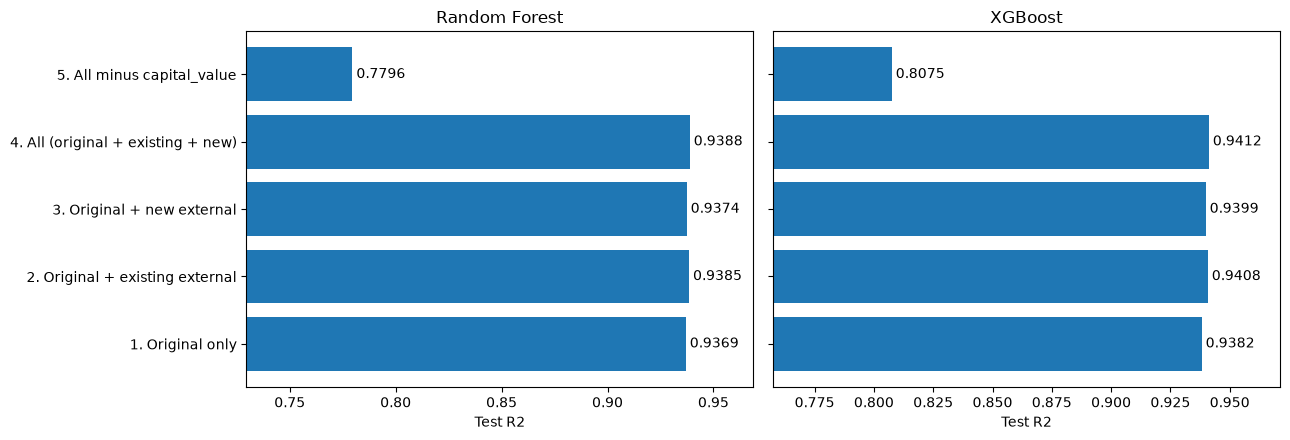

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, model_name in zip(axes, ["Random Forest", "XGBoost"]):
    sub = ablation[ablation["model"] == model_name]
    ax.barh(sub["config"], sub["R2"], color="tab:blue")
    for y_i, v in enumerate(sub["R2"]):
        ax.text(v, y_i, f" {v:.4f}", va="center")
    ax.set_xlim(sub["R2"].min() - 0.05, min(1.0, sub["R2"].max() + 0.03))
    ax.set_title(model_name)
    ax.set_xlabel("Test R2")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Without `capital_value`

Config 5 above: the full feature set (original + existing + new external) with `capital_value` removed. `land_value` was already dropped by the multicollinearity pruning, so no council valuation figure is left except `land_value_ratio`. Predicted-vs-actual and SHAP for both models.

Random Forest    RMSE=$253,040   MAE=$155,023   R2=0.7796
XGBoost          RMSE=$236,452   MAE=$148,154   R2=0.8075


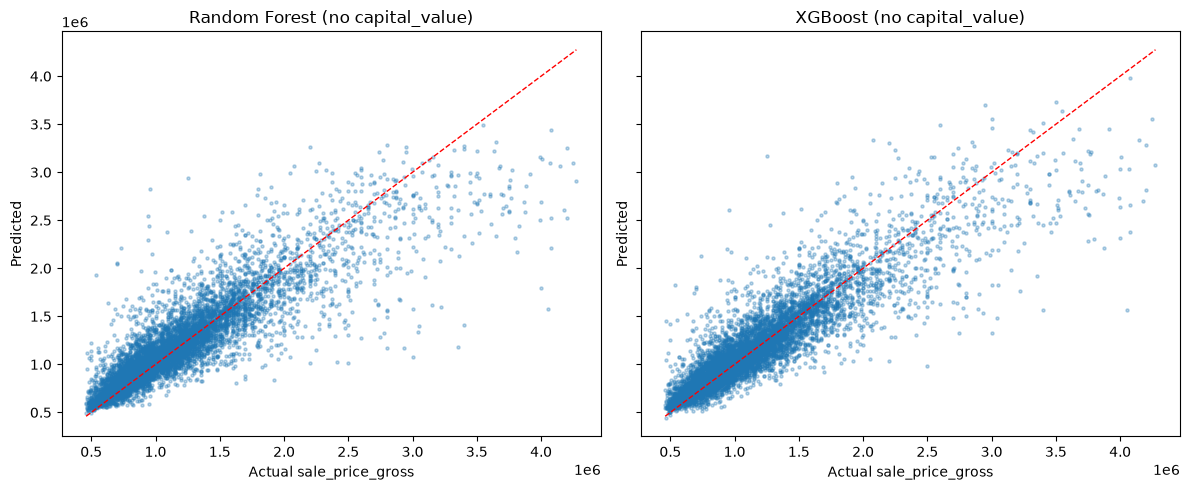

In [35]:
rf_nocv, xgb_nocv, cols_nocv = ablation_models["5. All minus capital_value"]
rf_pred_nocv = evaluate("Random Forest", rf_nocv, X_test_enc[cols_nocv], y_test_f)
xgb_pred_nocv = evaluate("XGBoost", xgb_nocv, X_test_enc[cols_nocv], y_test_f)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, name, pred in zip(axes, ["Random Forest", "XGBoost"], [rf_pred_nocv, xgb_pred_nocv]):
    ax.scatter(y_test_f, pred, s=5, alpha=0.3)
    lims = [y_test_f.min(), y_test_f.max()]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("Actual sale_price_gross")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name} (no capital_value)")
plt.tight_layout()
plt.show()

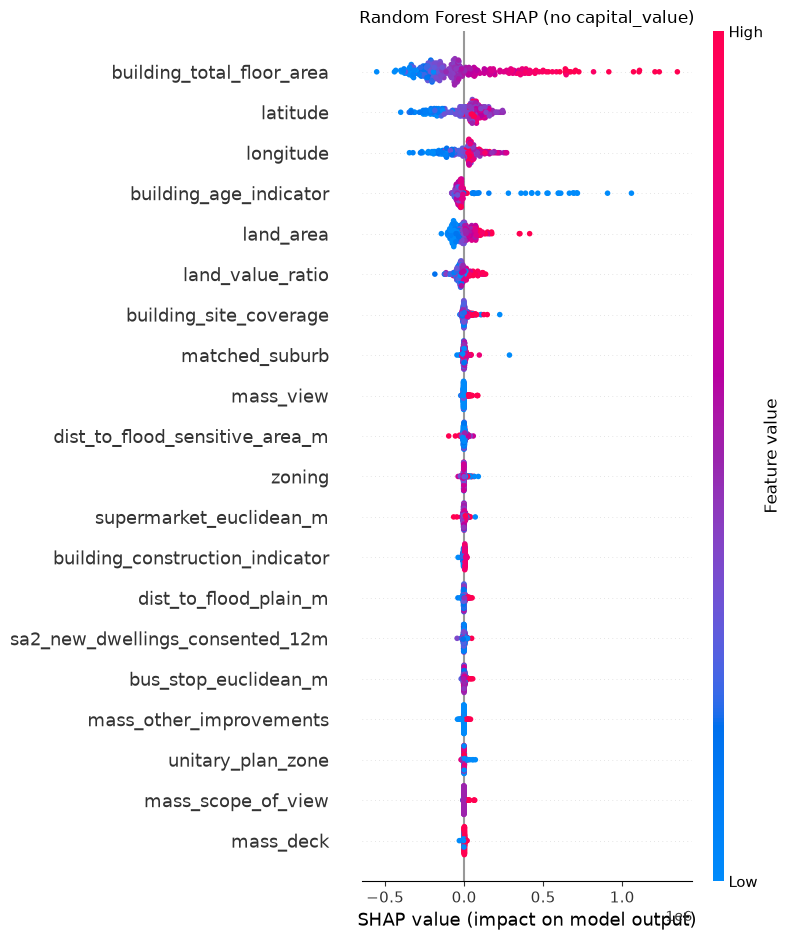

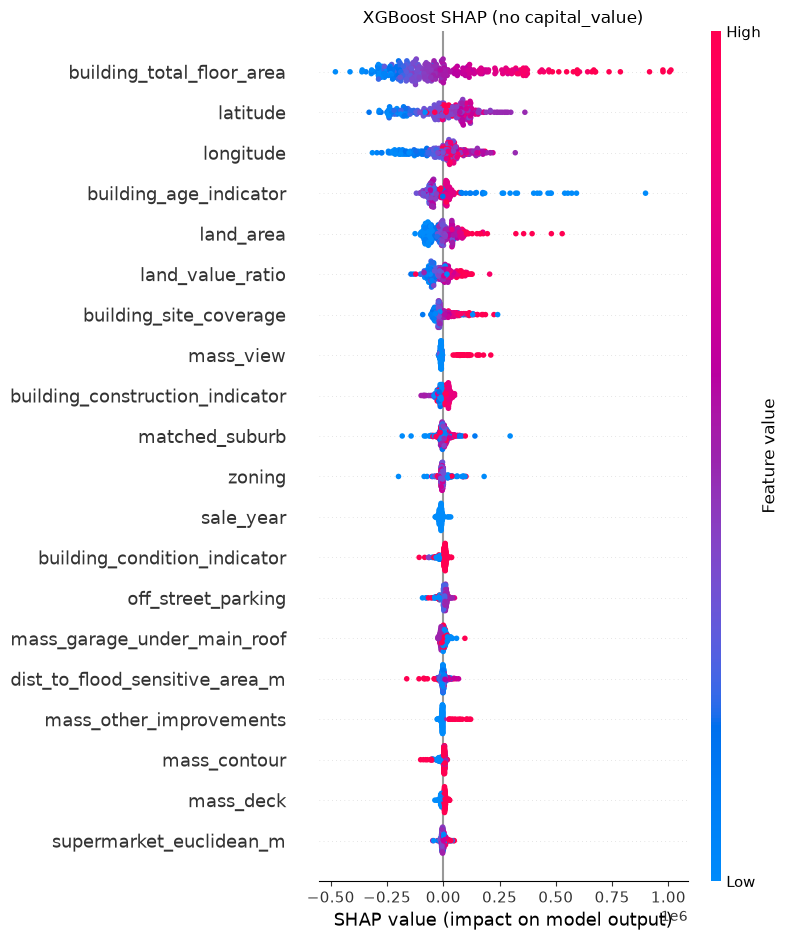

,feature,group,rf_mean_abs_shap,xgb_mean_abs_shap
16,building_total_floor_area,original,236599.323985,199642.500000
25,latitude,external_existing,103220.616552,103668.703125
24,longitude,external_existing,80531.221047,79286.265625
1,building_age_indicator,original,67005.966136,64204.621094
15,land_area,original,53127.180282,55023.851562
21,land_value_ratio,original,33112.790638,42687.039062
17,building_site_coverage,original,14592.753616,36588.898438
5,mass_view,original,7604.249350,20877.945312
3,building_construction_indicator,original,5363.865769,20555.107422
12,matched_suburb,external_existing,7737.803789,17569.687500


In [36]:
shap_sample_nocv = X_test_enc[cols_nocv].loc[shap_sample.index]

rf_sv_nocv = shap.TreeExplainer(rf_nocv).shap_values(shap_sample_nocv)
shap.summary_plot(rf_sv_nocv, shap_sample_nocv, max_display=20, show=False)
plt.title("Random Forest SHAP (no capital_value)")
plt.tight_layout()
plt.show()

xgb_sv_nocv = shap.TreeExplainer(xgb_nocv).shap_values(shap_sample_nocv)
shap.summary_plot(xgb_sv_nocv, shap_sample_nocv, max_display=20, show=False)
plt.title("XGBoost SHAP (no capital_value)")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": cols_nocv,
    "group": [group_of[c] for c in cols_nocv],
    "rf_mean_abs_shap": np.abs(rf_sv_nocv).mean(axis=0),
    "xgb_mean_abs_shap": np.abs(xgb_sv_nocv).mean(axis=0),
}).sort_values("xgb_mean_abs_shap", ascending=False).head(20)